# Visualize the results from the CSVs

In [12]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Tuple, Optional, List, Union
import warnings
import cartopy.crs as ccrs

### From CSVs

##### CO2 Emissions Analysis


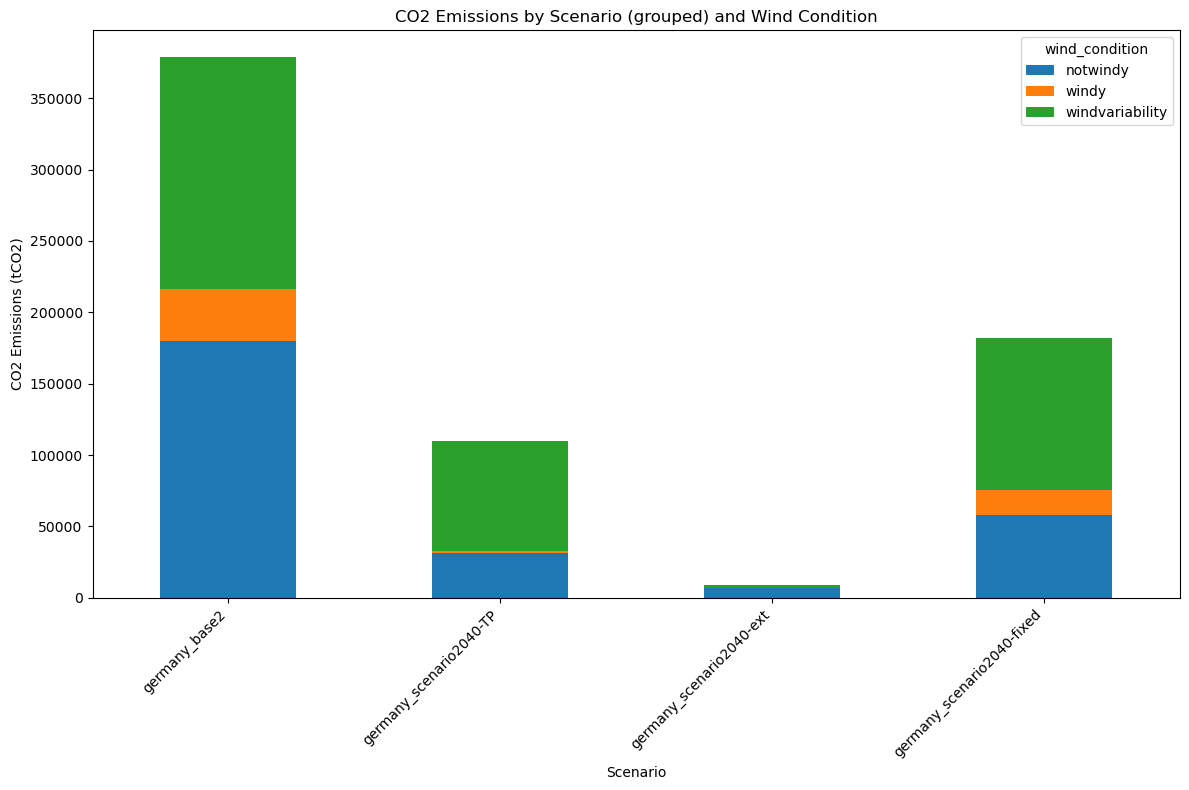

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
csv_path = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/run_comparison_summary_all_networks.csv"
summary_df = pd.read_csv(csv_path)

# Ensure wind_condition exists
if 'wind_condition' not in summary_df.columns:
    summary_df['wind_condition'] = summary_df['scenario'].astype(str).apply(lambda s: s.rsplit('_', 1)[-1] if '_' in s else '')
summary_df['wind_condition'] = summary_df['wind_condition'].fillna('unknown')

# Derive scenario base (everything before last underscore)
summary_df['scenario_base'] = summary_df['scenario'].astype(str).apply(lambda s: s.rsplit('_', 1)[0] if '_' in s else s)

# Aggregate CO2 by scenario_base x wind_condition
pivot_df = summary_df.pivot_table(
    index='scenario_base',
    columns='wind_condition',
    values='total_co2_emissions',
    aggfunc='sum',
    fill_value=0,
)

# Order common wind conditions if present
order = ['notwindy', 'windy', 'windvariability']
cols = [c for c in order if c in pivot_df.columns] + [c for c in pivot_df.columns if c not in order]
pivot_df = pivot_df[cols]

# Plot stacked bar grouped by scenario_base
fig, ax = plt.subplots(figsize=(12, 8))
pivot_df.plot(kind='bar', stacked=True, ax=ax)

ax.set_ylabel("CO2 Emissions (tCO2)")
ax.set_xlabel("Scenario")
ax.set_title("CO2 Emissions by Scenario (grouped) and Wind Condition")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### From NetCDFs

In [3]:
# Define the base results directory
RESULTS_DIR = Path("/home/lucakristin/Desktop/my_pypsa/pypsa-eur/results")
NETWORK_FILENAME = "base_s_450_elec_.nc"
NETWORKS_SUBFOLDER = "networks"

def parse_network_directory_name(dir_name: str) -> Optional[Tuple[str, str, str]]:
    """
    Parse a network directory name to extract metadata.
    
    Assumes directory names follow the pattern: germany_{scenario}_{wind_condition}
    
    Parameters
    ----------
    dir_name : str
        Directory name (e.g., 'germany_base2_notwindy')
    
    Returns
    -------
    Tuple[str, str, str] or None
        (scenario_name, wind_condition, transmission_setting) or None if invalid
        
    Examples
    --------
    >>> parse_network_directory_name('germany_base2_notwindy')
    ('base2', 'notwindy', 'fixed')
    >>> parse_network_directory_name('germany_scenario-ext_windy')
    ('scenario-ext', 'windy', 'extendable')
    """
    if not dir_name.startswith("germany_"):
        return None
    
    # Remove 'germany_' prefix
    remainder = dir_name[8:]  # len("germany_") = 8
    
    # Wind condition is the last component (notwindy, windy, windvariability)
    wind_conditions = ['notwindy', 'windy', 'windvariability']
    wind_condition = None
    
    for wc in wind_conditions:
        if remainder.endswith(wc):
            wind_condition = wc
            scenario_name = remainder[:-len(wc)-1]  # Remove wind condition and trailing '_'
            break
    
    if wind_condition is None:
        return None
    
    # Define transmission settings based on scenario name
    transmission_map = {
        'base': 'fixed',
        'base2': 'fixed',
        'scenario1': 'fixed',
        'scenario2': 'fixed',
        'scenario-ext': 'extendable + projects',
        'baseTP': 'projects',
        'base-ext': 'extendable',
        'scenario2040-TP': 'projects',
        'scenario2040-ext': 'extendable',
        'scenario2040-fixed': 'fixed'
    }
    
    transmission_setting = transmission_map.get(scenario_name, 'unknown')
    
    return (scenario_name, wind_condition, transmission_setting)


def load_networks_from_results(
    results_dir: Path = RESULTS_DIR,
    network_filename: str = NETWORK_FILENAME,
    networks_subfolder: str = NETWORKS_SUBFOLDER
) -> Dict[Tuple[str, str, str], pypsa.Network]:
    """
    Load all available solved networks from the results directory.
    
    Parameters
    ----------
    results_dir : Path
        Base results directory containing scenario subdirectories
    network_filename : str
        Name of the network file (default: 'base_s_450_elec_.nc')
    networks_subfolder : str
        Subfolder name containing network files (default: 'networks')
    
    Returns
    -------
    Dict[Tuple[str, str, str], pypsa.Network]
        Dictionary with tuple keys (scenario_name, wind_condition, transmission_setting)
    """
    networks = {}
    
    for scenario_dir in sorted(results_dir.iterdir()):
        if not scenario_dir.is_dir():
            continue
        
        # Parse the directory name
        metadata = parse_network_directory_name(scenario_dir.name)
        if metadata is None:
            continue
        
        # Check if network file exists
        network_path = scenario_dir / networks_subfolder / network_filename
        if not network_path.exists():
            print(f"[WARNING] Network file not found: {network_path}")
            continue
        
        try:
            network = pypsa.Network()
            network.import_from_netcdf(str(network_path))
            networks[metadata] = network
        except Exception as e:
            print(f"[ERROR] {e}")
    return networks

# Load networks
networks = load_networks_from_results()
print(f"Available networks: {len(networks)}")

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current:

Available networks: 12


### Results form comparing ALL Networks

In [4]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv"
n = networks[('scenario2040-fixed', 'windy', 'fixed')]
line_widths, bottlenecks = set_line_widths(top_count=None, csv_dir=csv_dir, n=n)

def set_line_widths(top_count, csv_dir=csv_dir, n=n):
    bottlenecks = pd.read_csv(csv_dir + "/bottlenecks.csv")
    if top_count == None:
        top_count = len(bottlenecks)
    top_bottlenecks = bottlenecks[0:top_count]
    top_ids = top_bottlenecks['line_id'].astype(str)
    idx_str = n.lines.index.astype(str)

    line_widths = pd.Series(1, index=n.lines.index)
    line_widths[idx_str.isin(top_ids)] = 4

    return line_widths, bottlenecks[0:top_count]

NameError: name 'set_line_widths' is not defined

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7b62f96b6710>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x7b62f96b6850>,
  'Line': <matplotlib.collections.LineCollection at 0x7b62f96b6990>},
 'flows': {}}

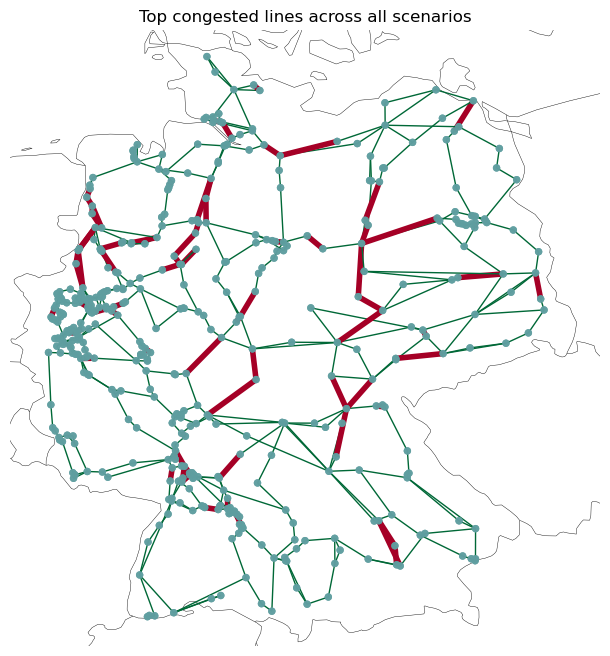

In [ ]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

n.plot(
    ax=ax,
    geomap=True,
    title="Top congested lines across all scenarios",
    bus_sizes=0.003,
    bus_alpha=0.7,
    line_widths= line_widths,
    line_colors= line_widths,
    line_cmap="RdYlGn_r",
)

In [ ]:
avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map.to_html("exploring_new.html")

### Comparing a subset of networks

In [ ]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/fixed/"
n = networks[('base2', 'windy', 'fixed')]
top_count = 30
line_widths, bottlenecks= set_line_widths(top_count, csv_dir, n)

avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map2=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map2.to_html("exploring_fixed.html")

print(bottlenecks)

    line_id     bus0     bus1  number_of_networks_congested  \
0       520  DE0 330  DE0 362                             5   
1       622   DE0 61   DE0 96                             5   
2        99   DE0 13   DE0 69                             5   
3        66  DE0 117  DE0 227                             4   
4       119  DE0 136  DE0 317                             4   
5        60  DE0 115   DE0 46                             4   
6        10    DE0 1  DE0 150                             4   
7       605  DE0 415   DE0 53                             4   
8       178   DE0 16  DE0 304                             4   
9       412  DE0 264  DE0 339                             4   
10       94  DE0 128  DE0 174                             4   
11       84  DE0 124  DE0 374                             4   
12       98   DE0 13  DE0 329                             4   
13       45  DE0 111  DE0 435                             4   
14       22  DE0 102   DE0 46                          

In [ ]:
csv_dir = "/home/lucakristin/Desktop/my_pypsa/pypsa-eur/summary_csv/wind/"
n = networks[('base2', 'windy', 'fixed')]
top_count = None
line_widths, bottlenecks = set_line_widths(top_count, csv_dir, n)

avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

map=n.explore(
    line_color=avg_loading_n,
    line_width= line_widths,
    line_cmap="YlOrRd",
    bus_alpha=0.2,
    line_alpha=0.5,
    bus_color = "lightblue",
)
map.to_html("exploring_wind.html")
print(bottlenecks)

   line_id     bus0     bus1  number_of_networks_congested  \
0      188  DE0 161    DE0 4                             1   
1      622   DE0 61   DE0 96                             1   
2      169  DE0 156   DE0 48                             1   
3       98   DE0 13  DE0 329                             1   
4      189  DE0 161   DE0 68                             1   

    list_of_networks_congested  average_loading_across_networks  \
0            base2_windy_fixed                            66.46   
1            base2_windy_fixed                            65.82   
2            base2_windy_fixed                            63.65   
3  base2_windvariability_fixed                            62.65   
4            base2_windy_fixed                            61.20   

   maximum_loading_across_networks  min_loading_across_networks  \
0                            66.46                        66.46   
1                            65.82                        65.82   
2                      